In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# configurações de plotagem
plt.style.use('seaborn-v0_8-darkgrid')
# paleta de cores oficial do tcu/acórdão 1889/2020
paleta_cores = {'Crítico': '#d9534f', 'alto': '#f0ad4e', 'médio': '#5bc0de', 'baixo': '#5cb85c', 'mínimo': '#a9a9a9'}
nomes_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
%matplotlib inline

In [2]:
# --- 1. carregar o dataset ---
DATASET_PATH = r'../FASE_1_INTELIGENCIA_REAL/2_dados_saida/dataset_benchmarks_enriquecido.csv'

try:
    df = pd.read_csv(DATASET_PATH)
    print(f"Dataset carregado com sucesso! Total de linhas: {len(df)}")
    display(df.head())
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em {DATASET_PATH}")

Dataset carregado com sucesso! Total de linhas: 494


,site,url_vulneravel,nome,cve,cvss,severity,epss,ncs,ppsi,impacto
0,https://owasp-juice-shop.local,https://owasp-juice-shop.local/rest/?id=693,XSS Reflected,CVE-2020-11022,6.1,MEDIUM,0.07666,1.6407,0.2607,0.69
1,https://owasp-juice-shop.local,https://owasp-juice-shop.local/api/main.js,Directory Listing,CVE-2007-0450,5.3,MEDIUM,0.01047,1.6407,0.2607,0.69
2,https://owasp-juice-shop.local,https://owasp-juice-shop.local/#/,Insecure Direct Object Reference,CVE-2010-0738,5.0,MEDIUM,0.03600,1.6407,0.2607,0.69
3,https://owasp-juice-shop.local,https://owasp-juice-shop.local/ftp/,Directory Listing,CVE-2007-0450,5.3,MEDIUM,0.02524,1.6407,0.2607,0.69
4,https://owasp-juice-shop.local,https://owasp-juice-shop.local/rest/robots.txt,SQL Injection,CVE-2015-5374,9.8,CRITICAL,0.58613,1.6407,0.2607,0.69


In [3]:
# --- 2. pré-processamento (normalização) ---
# isolar as duas dimensões para o clustering: epss (técnico) e ncs (negócio/tcu)
features = ['epss', 'ncs']
X = df[features].copy()

# o epss já está entre 0 e 1. precisamos normalizar o ncs.
scaler = MinMaxScaler()
df['ncs_normalizado'] = scaler.fit_transform(df[['ncs']])

# usaremos o epss original e o ncs normalizado
X_cluster = df[['epss', 'ncs_normalizado']]

print("Resumo estatístico após normalização:")
display(X_cluster.describe())

Resumo estatístico após normalização:


,epss,ncs_normalizado
count,494.000000,494.000000
mean,0.256535,0.494305
std,0.313183,0.325491
min,0.000150,0.000000
25%,0.010520,0.286502
50%,0.048515,0.452701
75%,0.521563,0.781081
max,0.985310,1.000000


O algoritmo sugeriu k=5, mas utilizaremos k=5 para cobrir todos os níveis de risco.


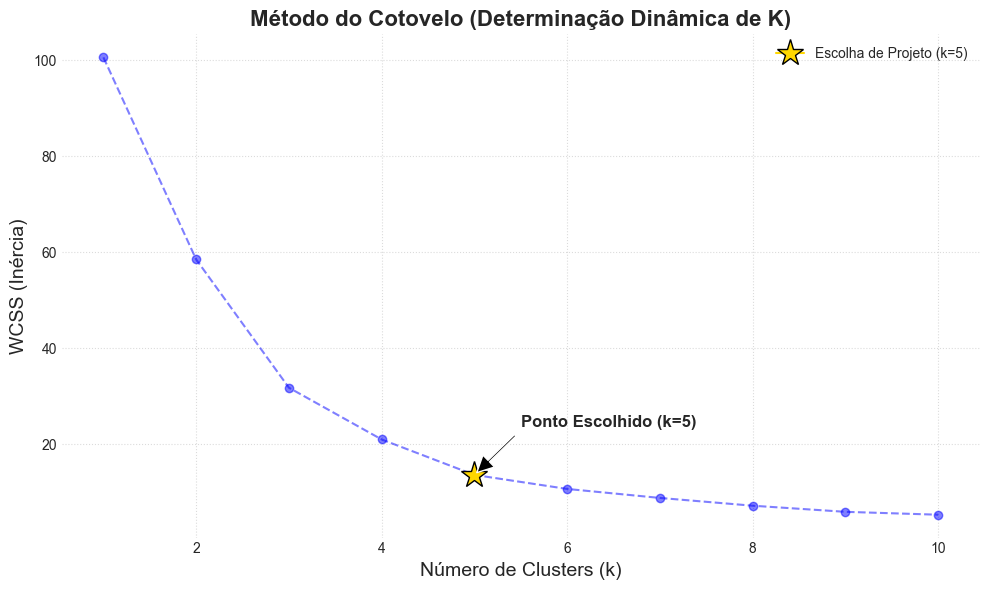

In [35]:
# --- 2.1 método do cotovelo dinâmico (elbow method) ---
from kneed import KneeLocator

wcss = []
k_range = range(1, 11)

for i in k_range:
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_cluster)
    wcss.append(km.inertia_)

# identificação dinâmica
kn = KneeLocator(k_range, wcss, curve='convex', direction='decreasing', S=0)
k_detectado = kn.elbow

# --- lógica de negócio: garantir k=5 para os 5 perfis de risco ---
# se o algoritmo detectar 4 ou menos, forçamos 5 para permitir a classificação completa.
k_ideal = k_detectado if k_detectado >= 5 else 5

print(f"O algoritmo sugeriu k={k_ideal}, mas utilizaremos k={k_ideal} para cobrir todos os níveis de risco.")

# --- plotagem padronizada ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b', alpha=0.5)

# título e labels
plt.title('Método do Cotovelo (Determinação Dinâmica de K)', fontsize=16, weight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=14)
plt.ylabel('WCSS (Inércia)', fontsize=14)

# elementos dinâmicos no gráfico


# destaque com estrela no k_ideal (o que usaremos de fato)
plt.plot(k_ideal, wcss[k_ideal-1], marker='*', markersize=20, 
         color='gold', markeredgecolor='black', label=f'Escolha de Projeto (k={k_ideal})')

plt.annotate(f'Ponto Escolhido (k={k_ideal})',
             xy=(k_ideal, wcss[k_ideal-1]),
             xytext=(k_ideal + 0.5, wcss[k_ideal-1] + 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=12, fontweight='bold')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

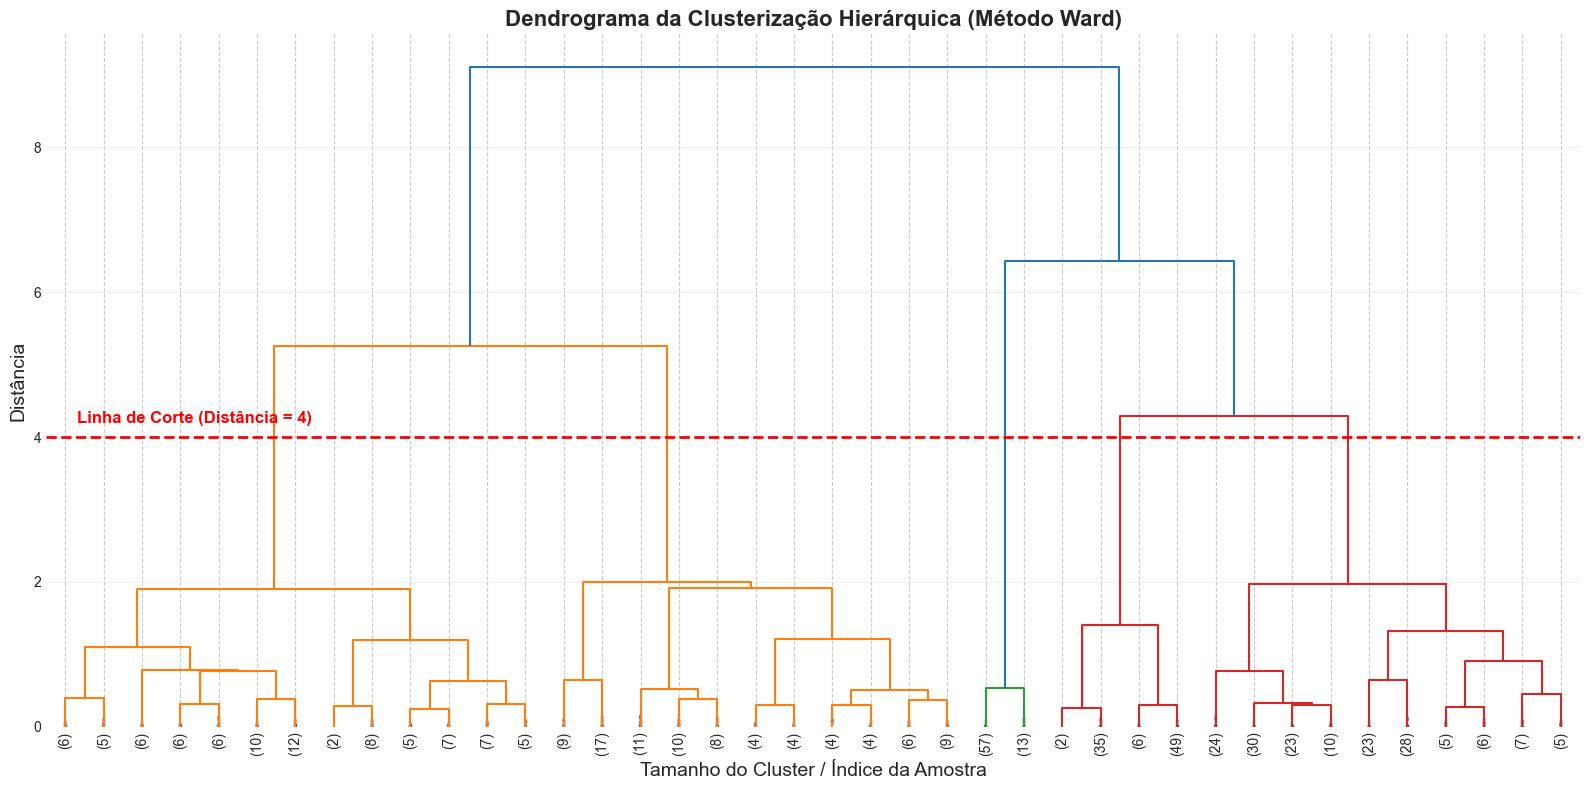

In [37]:
# --- 2.2 dendrograma (clustering hierárquico) ---
plt.figure(figsize=(16, 8))

# cálculo da ligação (linkage) utilizando o método de ward
Z = linkage(X_cluster, method='ward')

# capturamos o eixo (ax) para permitir desenhos customizados (como a linha de corte)
ax = plt.gca()

# geração do dendrograma
dendrogram(
    Z, 
    truncate_mode='lastp', 
    p=40, 
    show_leaf_counts=True, 
    leaf_rotation=90., 
    leaf_font_size=10., 
    show_contracted=True,
    ax=ax
)

# --- padronização: linha de corte e texto ---
altura_de_corte = 4
# adiciona a linha de corte vermelha, tracejada e mais espessa (linewidth=2)
ax.axhline(y=altura_de_corte, color='r', linestyle='--', linewidth=2)

# adiciona o texto explicativo logo acima da linha
ax.text(
    x=ax.get_xlim()[1] * 0.02, 
    y=altura_de_corte + (ax.get_ylim()[1] * 0.02), 
    s=f'Linha de Corte (Distância = {altura_de_corte})', 
    color='red', 
    fontweight='bold',
    fontsize=12
)

# configurações de títulos e eixos padronizadas
plt.title('Dendrograma da Clusterização Hierárquica (Método Ward)', fontsize=16, weight='bold')
plt.xlabel('Tamanho do Cluster / Índice da Amostra', fontsize=14)
plt.ylabel('Distância', fontsize=14)

# adição de grade para facilitar a leitura das distâncias
plt.grid(True, which='both', axis='y', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# --- 3. execução do k-means (k=5) e definição dos perfis de risco ---
k_ideal = 5
kmeans = KMeans(n_clusters=k_ideal, init='k-means++', n_init='auto', random_state=42)
df['kmeans_cluster_raw'] = kmeans.fit_predict(X_cluster)

# re-rotulando os clusters para nomes significativos baseados no risco
centroides_analise = df.groupby('kmeans_cluster_raw')[['epss', 'ncs_normalizado']].mean()
centroides_analise['risk_score'] = centroides_analise['epss'] + centroides_analise['ncs_normalizado']
centroides_ordenados = centroides_analise.sort_values(by='risk_score', ascending=False)
mapa_rotulos = {indice: nome for indice, nome in zip(centroides_ordenados.index, nomes_perfis)}

df['PRP'] = df['kmeans_cluster_raw'].map(mapa_rotulos)
print("Coluna 'PRP' (Perfil de Risco Proposto) criada com sucesso.")

# padronizando cvss para comparação
mapa_cvss = {'CRITICAL': 'Crítico', 'HIGH': 'Alto', 'MEDIUM': 'Médio', 'LOW': 'Baixo'}
df['cvss_padronizado'] = df['severity'].str.upper().map(mapa_cvss)


Coluna 'PRP' (Perfil de Risco Proposto) criada com sucesso.


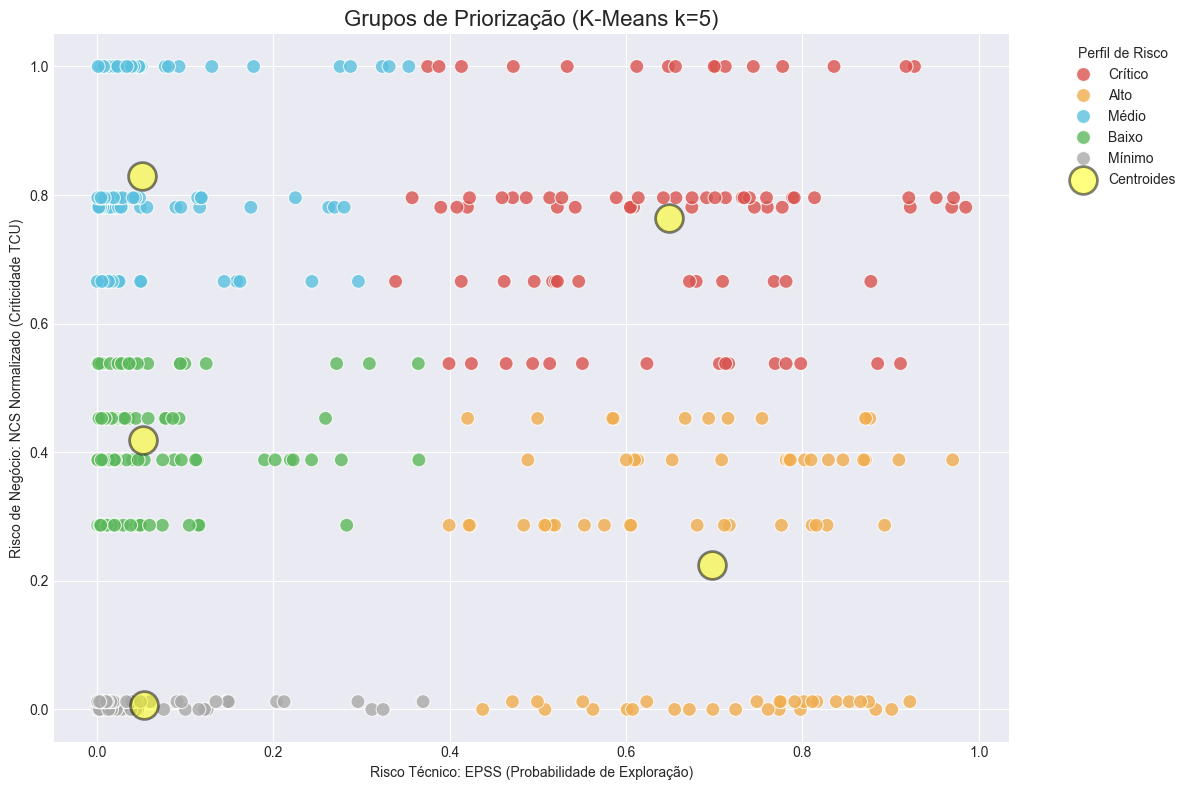

In [7]:
# --- 4. visualização dos 5 perfis de risco (k-means) ---
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df, 
    x='epss', 
    y='ncs_normalizado', 
    hue='PRP', 
    palette=paleta_cores, 
    hue_order=nomes_perfis, 
    s=100, 
    alpha=0.8
)

# destacando os centroides com círculos amarelos
centroides_reais = kmeans.cluster_centers_
plt.scatter(
    centroides_reais[:, 0],
    centroides_reais[:, 1],
    s=400,                  # tamanho grande
    c='yellow',             # cor amarela
    marker='o',             # marcador de círculo
    label='Centroides',
    alpha=0.5,              # 50% de transparência
    edgecolor='black',      # borda preta para destaque
    linewidth=2
)

plt.title('Grupos de Priorização (K-Means k=5)', fontsize=16)
plt.xlabel('Risco Técnico: EPSS (Probabilidade de Exploração)')
plt.ylabel('Risco de Negócio: NCS Normalizado (Criticidade TCU)')
plt.legend(title='Perfil de Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Gerando o gráfico comparativo padronizado 'Antes vs. Depois'...


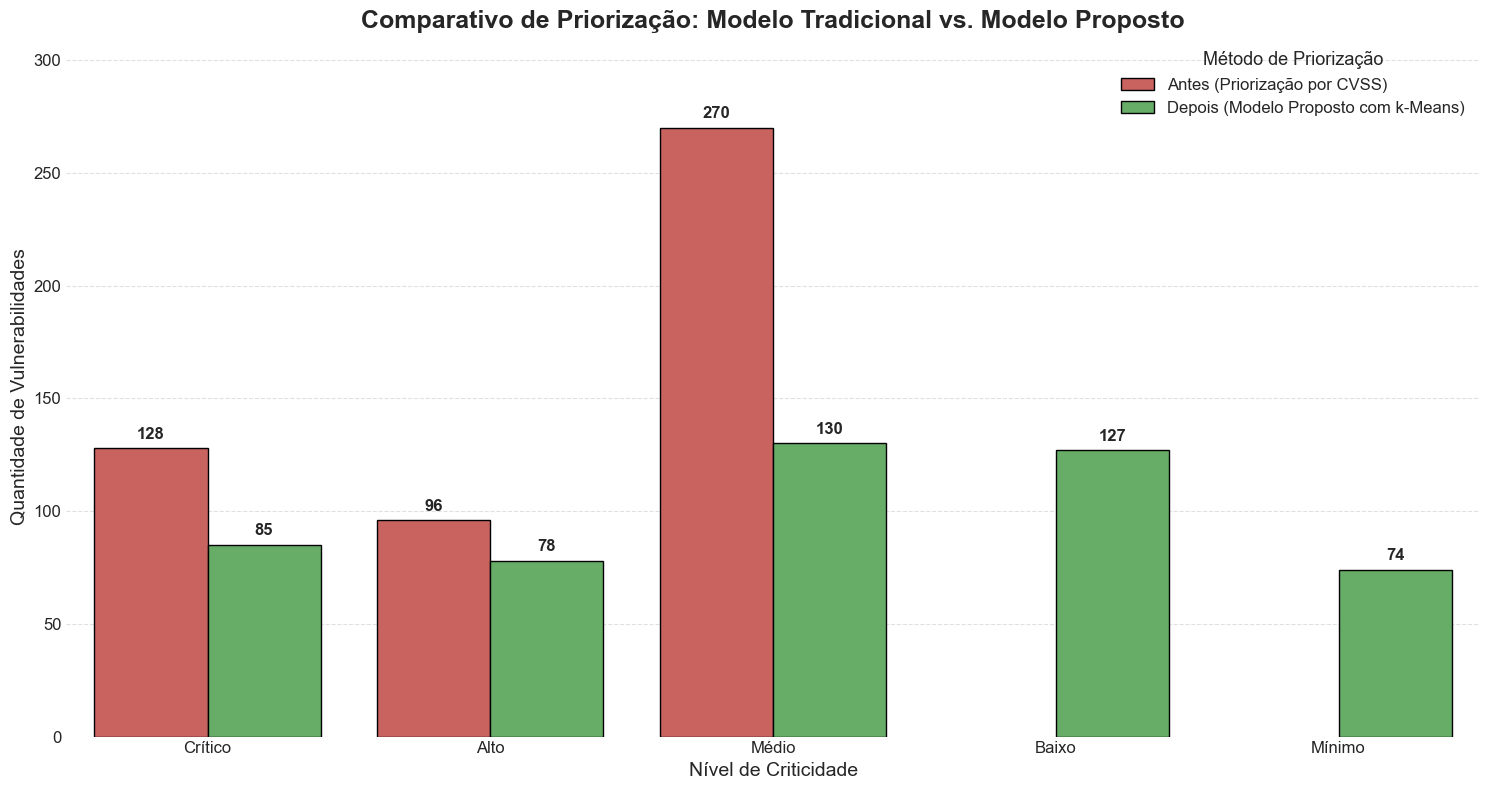

In [16]:
# --- 5. gráfico comparativo padronizado: antes (cvss) vs depois (modelo proposto) ---

# 1. preparação e limpeza de dados
ordem_criticidade = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# garantindo a correção de strings e padronização
mapa_limpeza = {'Crtico': 'Crítico', 'Mdio': 'Médio', 'Mnimo': 'Mínimo'}
df['cvss_padronizado'] = df['cvss_padronizado'].replace(mapa_limpeza)
df['PRP'] = df['PRP'].replace(mapa_limpeza)

# 2. estruturação dos dataframes para plotagem (long-format)
dados_antes = df['cvss_padronizado'].value_counts().reset_index()
dados_antes.columns = ['Criticidade', 'Contagem']
dados_antes['Método'] = 'Antes (Priorização por CVSS)'

dados_depois = df['PRP'].value_counts().reset_index()
dados_depois.columns = ['Criticidade', 'Contagem']
dados_depois['Método'] = 'Depois (Modelo Proposto com k-Means)'

# combinar os cenários
df_grafico = pd.concat([dados_antes, dados_depois])

# 3. gerando o gráfico comparativo lado a lado
print("\nGerando o gráfico comparativo padronizado 'Antes vs. Depois'...")
plt.figure(figsize=(15, 8))

# cores padronizadas do original
# vermelho para o legado, verde para a proposta
paleta_metodo = {
    'Antes (Priorização por CVSS)': '#d9534f', 
    'Depois (Modelo Proposto com k-Means)': '#5cb85c'
}

ax = sns.barplot(
    data=df_grafico,
    x='Criticidade',
    y='Contagem',
    hue='Método',
    order=ordem_criticidade,
    palette=paleta_metodo,
    edgecolor='black',
    linewidth=1
)

# 4. adicionando rótulos de dados (data labels) no topo das barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=12, weight='bold')

# 5. configurações finais de layout
ax.set_title('Comparativo de Priorização: Modelo Tradicional vs. Modelo Proposto', fontsize=18, weight='bold')
ax.set_xlabel('Nível de Criticidade', fontsize=14)
ax.set_ylabel('Quantidade de Vulnerabilidades', fontsize=14)
ax.legend(title='Método de Priorização', title_fontsize='13', fontsize='12', loc='upper right')

# ajuste de escala para os rótulos não cortarem
ax.set_ylim(0, df_grafico['Contagem'].max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

--- Tabela de Médias por Perfil de Risco ---


,EPSS (Média),NCS Normalizado (Média)
PRP,,
Crítico,0.648522,0.764729
Alto,0.697847,0.224385
Médio,0.050991,0.830031
Baixo,0.051823,0.419433
Mínimo,0.053536,0.006897


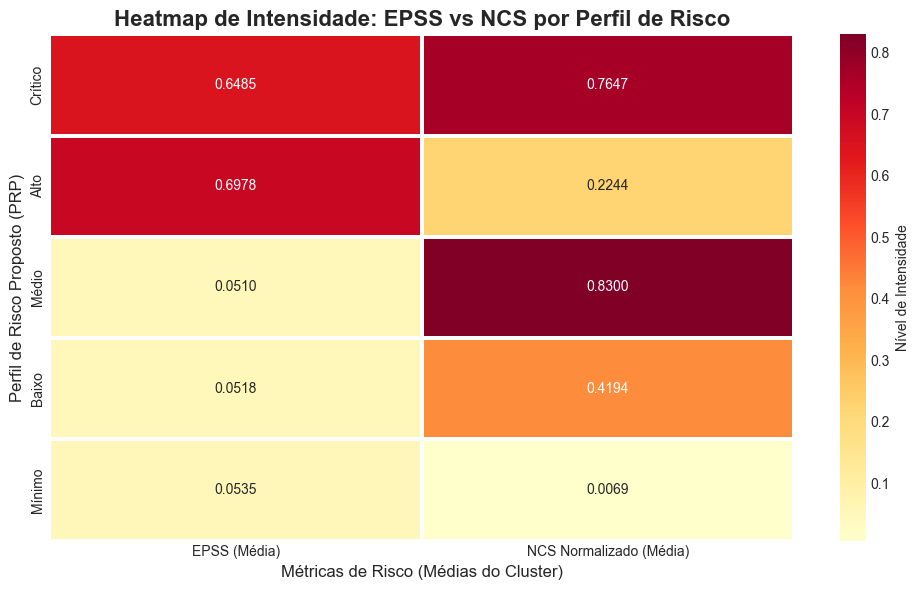


--- Correlação Estatística Simples entre as Variáveis ---
                     epss  ncs_normalizado
epss             1.000000         0.003373
ncs_normalizado  0.003373         1.000000


In [41]:
# --- 8. tabela de médias e heatmap por perfil de risco ---

# 1. preparação dos dados e ordenação
ordem_perfis = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# criando a tabela de médias (tabelinha de correlação por perfil)
# agrupamos pelo perfil de risco proposto (prp) e calculamos a média das métricas
tabela_perfis = df.groupby('PRP')[['epss', 'ncs_normalizado']].mean().reindex(ordem_perfis)

# renomeando as colunas para o formato final do relatório
tabela_perfis.columns = ['EPSS (Média)', 'NCS Normalizado (Média)']

# exibição da tabela no console/notebook
print("--- Tabela de Médias por Perfil de Risco ---")
display(tabela_perfis) # ou print(tabela_perfis)

# 2. gerando o heatmap conforme a matriz de risco epss vs ncs
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_perfis, 
    annot=True,          # exibe os valores numéricos
    cmap='YlOrRd',       # paleta amarelo -> vermelho (padrão de risco)
    fmt=".4f",           # quatro casas decimais para maior precisão técnica
    linewidths=1.5,      # divisória entre as células para clareza
    cbar_kws={'label': 'Nível de Intensidade'}
)

# configurações de título e eixos seguindo o padrão original
plt.title('Heatmap de Intensidade: EPSS vs NCS por Perfil de Risco', fontsize=16, weight='bold')
plt.xlabel('Métricas de Risco (Médias do Cluster)', fontsize=12)
plt.ylabel('Perfil de Risco Proposto (PRP)', fontsize=12)

# ajuste fino para não cortar rótulos
plt.tight_layout()
plt.show()

# --- 3. matriz de correlação simples (opcional, para validação estatística) ---
print("\n--- Correlação Estatística Simples entre as Variáveis ---")
print(df[['epss', 'ncs_normalizado']].corr())

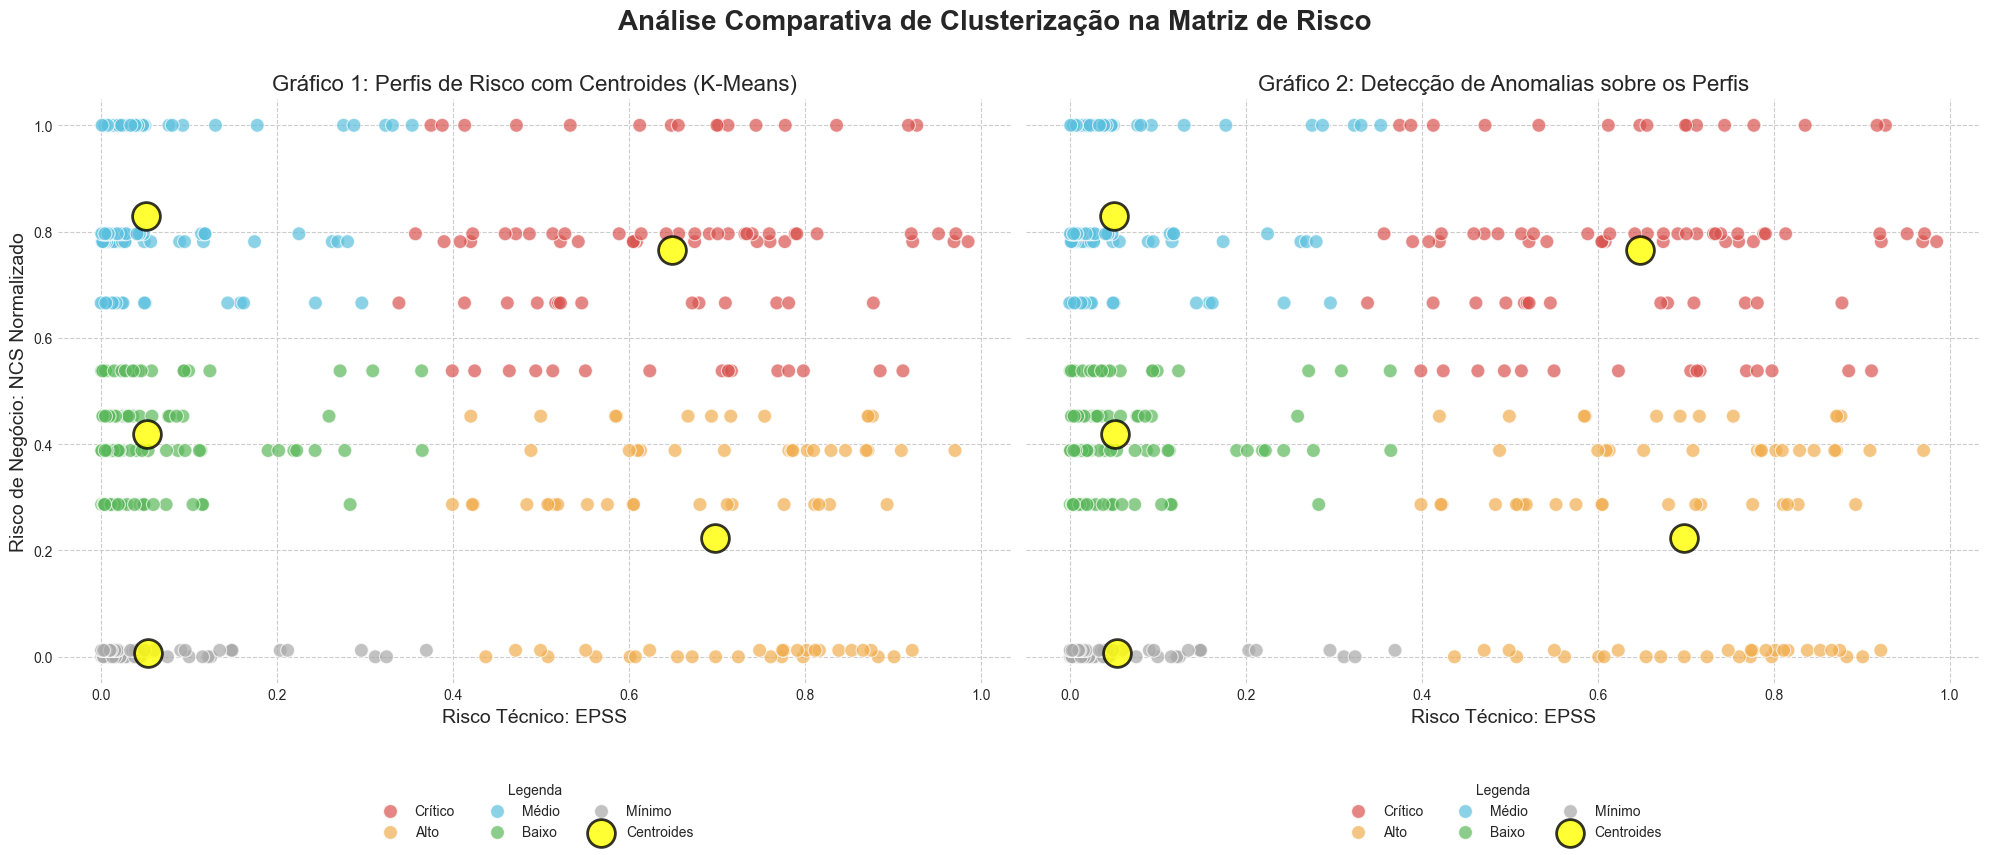

Quantidade de Outliers identificados pelo DBSCAN: 0


In [15]:
# --- 6. comparação lado a lado: padronizada e corrigida (centroides no lugar certo) ---

# 1. configurações de estilo e variáveis
paleta_cores = {
    'Crítico': '#d9534f', 'alto': '#f0ad4e', 'médio': '#5bc0de',
    'Baixo': '#5cb85c', 'mínimo': '#a9a9a9'
}
ordem_hue = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# executando dbscan no novo set (x_cluster) para identificar outliers
# (ajuste eps/min_samples se necessário para este set de dados)
dbscan = DBSCAN(eps=0.3, min_samples=3)
df['is_outlier'] = (dbscan.fit_predict(X_cluster) == -1)

centroides_corretos = kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharex=True, sharey=True)
fig.suptitle('Análise Comparativa de Clusterização na Matriz de Risco', fontsize=20, weight='bold')

# configuração de grid (fundo branco com grade discreta)
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

# --- gráfico 1: k-means puro (perfis de risco) ---
ax1 = axes[0]
sns.scatterplot(
    data=df, x='epss', y='ncs_normalizado', hue='PRP', 
    hue_order=ordem_hue, palette=paleta_cores, s=100, alpha=0.7, ax=ax1
)

# adiciona centroides amarelos (estilo do original)
ax1.scatter(
    centroides_corretos[:, 0], centroides_corretos[:, 1],
    s=400, c='yellow', marker='o', label='Centroides',
    alpha=0.8, edgecolor='black', linewidth=2, zorder=3
)

ax1.set_title('Gráfico 1: Perfis de Risco com Centroides (K-Means)', fontsize=16)
ax1.set_xlabel('Risco Técnico: EPSS', fontsize=14)
ax1.set_ylabel('Risco de Negócio: NCS Normalizado', fontsize=14)
ax1.legend(title='Legenda', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)


# --- gráfico 2: k-means + outliers (dbscan) ---
ax2 = axes[1]
df_clusters = df[~df['is_outlier']]
df_outliers = df[df['is_outlier']]

# plota pontos normais coloridos pelo k-means
sns.scatterplot(
    data=df_clusters, x='epss', y='ncs_normalizado', hue='PRP',
    hue_order=ordem_hue, palette=paleta_cores, s=100, alpha=0.7, ax=ax2
)

# plota outliers com 'x' preto forte (estilo do original)
if not df_outliers.empty:
    ax2.scatter(
        df_outliers['epss'], df_outliers['ncs_normalizado'],
        marker='X', color='black', s=250, label='Outlier (DBSCAN)',
        edgecolor='white', linewidth=1.5, zorder=4
    )

# adiciona os mesmos centroides na posição correta
ax2.scatter(
    centroides_corretos[:, 0], centroides_corretos[:, 1],
    s=400, c='yellow', marker='o', label='Centroides',
    alpha=0.8, edgecolor='black', linewidth=2, zorder=3
)

ax2.set_title('Gráfico 2: Detecção de Anomalias sobre os Perfis', fontsize=16)
ax2.set_xlabel('Risco Técnico: EPSS', fontsize=14)
ax2.set_ylabel('') # removido pois sharey=true
ax2.legend(title='Legenda', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

# ajuste fino de layout
plt.subplots_adjust(bottom=0.2)
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # ajustado para o título não cortar
plt.show()


print(f"Quantidade de Outliers identificados pelo DBSCAN: {(df['cluster_dbscan'] == -1).sum()}")

In [11]:
# --- 8. exportação do dataset final ---
import os
OUTPUT_DIR = '2_resultados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'dataset_clusterizado_final.csv')
df.to_csv(OUTPUT_FILE, index=False)
print(f"Dataset exportado com sucesso para: {OUTPUT_FILE}")

Dataset exportado com sucesso para: 2_resultados\dataset_clusterizado_final.csv
